## Setup

In [1]:
# Set project root to ChessClassification

import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if project_root not in sys.path:
    sys.path.append(project_root)

print(f"Project root added to path: {project_root}")

Project root added to path: /home/zmoraj/ChessClassification


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
from torchvision import transforms, models
from src.network.training import train
from src.network.evaluation import evaluate, analyze_model_performance, evaluate_with_solver
from src.preprocessing.dataset import ChessBoardDataset
from src.utils.dataset_utils import calculate_stats, build_transforms
from src.utils.plotting import visualize_test_samples, visualize_test_samples_with_solver, plot_training_history

In [3]:
# Load data 

TRAIN_DATA_ROOT = os.path.join(project_root, "data/train/synthetic")
VAL_DATA_ROOT = os.path.join(project_root, "data/validation/synthetic")
TEST_REAL_DATA_ROOT = os.path.join(project_root, "data/test/real")
BATCH_SIZE = 2
NUM_WORKERS = 4
SIZE = 112

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

# Compute statistics
train_mean, train_std, test_mean, test_std = calculate_stats(TRAIN_DATA_ROOT, TEST_REAL_DATA_ROOT, SIZE, SIZE, NUM_WORKERS)

# Build final datasets and DataLoaders
baseline_config = {} 
train_transform = build_transforms(train_mean, train_std, config=baseline_config)
test_transform = build_transforms(test_mean, test_std, config=baseline_config)

train_dataset = ChessBoardDataset(root_dir=TRAIN_DATA_ROOT, transform=train_transform, padding=0.0)
val_dataset = ChessBoardDataset(root_dir=VAL_DATA_ROOT, transform=train_transform, padding=0.0)
test_real_dataset = ChessBoardDataset(root_dir=TEST_REAL_DATA_ROOT, transform=test_transform, padding=0.0)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_real_loader = DataLoader(test_real_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

device: cuda
Training samples: 1800 | Test samples: 205
Computing mean and std for training data...


Calculating Stats: 100%|██████████| 113/113 [00:48<00:00,  2.31it/s]



Calculated training mean: [0.7266303300857544, 0.6799918413162231, 0.5675383806228638]
Calculated training std:  [0.08976191282272339, 0.09742976725101471, 0.08831595629453659]

Computing mean and std for test data...


Calculating Stats: 100%|██████████| 13/13 [00:06<00:00,  2.07it/s]


Calculated test mean: [0.7061654329299927, 0.6712028980255127, 0.5853357911109924]
Calculated test std:  [0.13416209816932678, 0.14039230346679688, 0.1279790848493576]



In [4]:
# Define DinoTransformer model

class DinoTransformer(nn.Module):
    def __init__(self, num_classes=13, d_square=112, nhead=8, num_layers=4):
        super().__init__()

        self.d_square = d_square
        
        # Load DINOv2 Small as the backbone
        self.backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14', verbose=False)
        
        # Freeze the backbone
        self.backbone.eval()
        for param in self.backbone.parameters():
            param.requires_grad = False
            
        # Positional encoding
        self.pos_encoder = nn.Parameter(torch.randn(1, 64, 768))
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=768, 
            nhead=nhead, 
            dim_feedforward=768 * 4, 
            batch_first=True, 
            dropout=0.1
        )
        
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Classification head
        self.classifier = nn.Linear(768, num_classes)

    def forward(self, x):
        if x.dim() == 5:
            B = x.size(0)
            x = x.view(B * 64, 3, self.d_square, self.d_square)
        elif x.dim() == 4:
            B = x.size(0) // 64
        else:
            raise ValueError(f"Unexpected input shape: {x.shape}")
            
        # Backbone forward pass
        with torch.no_grad():
            features = self.backbone(x)
            
        # Reshape for Transformer Encoder
        features = features.view(B, 64, 768)

        # Add positional encoding
        features = features + self.pos_encoder
        
        # Pass through Transformer Encoder
        transformer_out = self.transformer(features)

        # Classification
        logits = self.classifier(transformer_out)
        
        return logits.view(B * 64, -1)

In [5]:
# Initialize model

model = DinoTransformer().to(device)

/home/zmoraj/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/zmoraj/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/zmoraj/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /home/zmoraj/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth
100%|██████████| 330M/330M [00:06<00:00, 57.2MB/s] 


## Training

Training on cuda for 15 epochs...


Training Progress:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 1/15 | Train: Loss=0.2074 Acc=0.9359  Val: Loss=0.1323 Acc=0.9570   [Saved Best]
Epoch 2/15 | Train: Loss=0.0840 Acc=0.9722  Val: Loss=0.1163 Acc=0.9610   [Saved Best]
Epoch 3/15 | Train: Loss=0.0543 Acc=0.9826  Val: Loss=0.1225 Acc=0.9603  
Epoch 4/15 | Train: Loss=0.0391 Acc=0.9875  Val: Loss=0.0976 Acc=0.9707   [Saved Best]
Epoch 5/15 | Train: Loss=0.0295 Acc=0.9904  Val: Loss=0.1316 Acc=0.9624  
Epoch 6/15 | Train: Loss=0.0208 Acc=0.9934  Val: Loss=0.1156 Acc=0.9642  
Epoch 7/15 | Train: Loss=0.0149 Acc=0.9951  Val: Loss=0.1107 Acc=0.9718   [Saved Best]
Epoch 8/15 | Train: Loss=0.0114 Acc=0.9963  Val: Loss=0.1136 Acc=0.9694  
Epoch 9/15 | Train: Loss=0.0083 Acc=0.9976  Val: Loss=0.1006 Acc=0.9740   [Saved Best]
Epoch 10/15 | Train: Loss=0.0040 Acc=0.9986  Val: Loss=0.0996 Acc=0.9771   [Saved Best]
Epoch 11/15 | Train: Loss=0.0032 Acc=0.9990  Val: Loss=0.1321 Acc=0.9712  
Epoch 12/15 | Train: Loss=0.0016 Acc=0.9995  Val: Loss=0.1020 Acc=0.9772   [Saved Best]
Epoch 13/15 | Trai

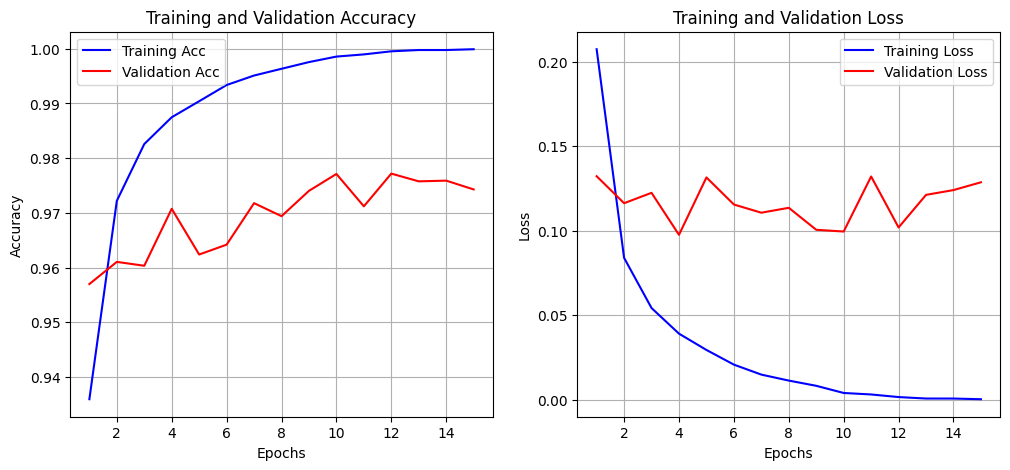

In [6]:
# Training loop

# Configuration
lr = 1e-4
num_epochs = 15
criterion = nn.CrossEntropyLoss()
params = filter(lambda p: p.requires_grad, model.parameters())
optimizer = optim.Adam(params, lr=lr)
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

# Training
best_model, history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=num_epochs,
    device=device,
    save_path=os.path.join(project_root, 'models/dino_b_transformer.pth')
)

# Plotting train and validation statistics
plot_training_history(history)

## Evaluation

In [9]:
# Evaluation on real test data

square_acc, board_acc = evaluate(best_model, test_real_loader, device)

print(f"Square accuracy: {square_acc:.2f}")
print(f"Board accuracy: {board_acc:.2f}")

Starting Evaluation on 205 boards...


Evaluating:   0%|          | 0/103 [00:00<?, ?it/s]

Square accuracy: 81.45
Board accuracy: 0.00


In [11]:
# Evaluation with solver on real test data

test_real_dataset.return_fen = False
square_acc, board_acc = evaluate_with_solver(best_model, test_real_loader, device)

print(f"Square accuracy: {square_acc:.2f}")
print(f"Board accuracy: {board_acc:.2f}")

Starting Solver Evaluation on 205 boards...


Solver Inference:   0%|          | 0/103 [00:00<?, ?it/s]

Square accuracy: 82.99
Board accuracy: 0.00
